# MScFE 620 Derivative Pricing - Group Work Project 2

**Group:** 15356

**Team members and attribution**

| Role | Team member | Location | Contribution |
| --- | --- | --- | --- |
| Team Member A - Stochastic Volatility Modeler | Peter Biyela | Zambia | Heston model pricing, Greeks, and American call comparison |
| Team Member B - Jump Modeler | Bukunmi Akinyemi | Nigeria | Merton jump model pricing, Greeks, and barrier put comparison |
| Team Member C - Model Validator | Ijaz Hussain | Pakistan | Put-call parity checks, strike sweep validation, and final review |

This notebook consolidates the group work into one executable artifact. All reported prices are generated by the code below and rounded to the nearest cent in the summary tables.


## Shared setup

The assignment parameters are:

- Initial stock price: 80
- Risk-free rate: 5.5% per year
- Base volatility / Heston volatility-of-variance parameter: 35%
- Time to maturity: 0.25 years
- ATM strike: 80

The Heston variance process uses `v0 = 0.032`, `kappa = 1.85`, and `theta = 0.045`. The Merton jump process uses jump mean `-0.5` and jump volatility `0.22`.


In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

S0 = 80.0
R = 0.055
SIGMA = 0.35
T = 0.25
K_ATM = 80.0
DISCOUNT = np.exp(-R * T)

V0 = 0.032
KAPPA = 1.85
THETA = 0.045
XI = SIGMA

MU_JUMP = -0.5
DELTA_JUMP = 0.22

N_PATHS = 250_000
N_STEPS = 126
BUMP = 0.01 * S0

In [57]:
def heston_terminal_ratios(rho, n_paths=N_PATHS, n_steps=N_STEPS, seed=620):
    # Simulate S_T / S_0 under the risk-neutral Heston model.
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    stock_ratio = np.ones(n_paths, dtype=float)
    variance = np.full(n_paths, V0, dtype=float)

    for _ in range(n_steps):
        z_stock = rng.standard_normal(n_paths)
        z_independent = rng.standard_normal(n_paths)
        z_variance = rho * z_stock + np.sqrt(1.0 - rho**2) * z_independent

        variance_positive = np.maximum(variance, 0.0)
        stock_ratio *= np.exp(
            (R - 0.5 * variance_positive) * dt
            + np.sqrt(variance_positive * dt) * z_stock
        )
        variance = np.maximum(
            variance
            + KAPPA * (THETA - variance_positive) * dt
            + XI * np.sqrt(variance_positive * dt) * z_variance,
            0.0,
        )

    return stock_ratio


def discounted_option_price_from_ratios(initial_stock, strike, option_type, terminal_ratios):
    terminal_stock = initial_stock * terminal_ratios
    if option_type == "call":
        payoff = np.maximum(terminal_stock - strike, 0.0)
    elif option_type == "put":
        payoff = np.maximum(strike - terminal_stock, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    discounted_payoff = DISCOUNT * payoff
    return discounted_payoff.mean(), discounted_payoff.std(ddof=1) / np.sqrt(len(discounted_payoff))


def finite_difference_greeks(terminal_ratios, strike, option_type, bump=BUMP):
    price_down, _ = discounted_option_price_from_ratios(S0 - bump, strike, option_type, terminal_ratios)
    price_mid, _ = discounted_option_price_from_ratios(S0, strike, option_type, terminal_ratios)
    price_up, _ = discounted_option_price_from_ratios(S0 + bump, strike, option_type, terminal_ratios)
    delta = (price_up - price_down) / (2 * bump)
    gamma = (price_up - 2 * price_mid + price_down) / (bump**2)
    return price_mid, delta, gamma


def jump_compensator(mu_j=MU_JUMP, delta_j=DELTA_JUMP):
    return np.exp(mu_j + 0.5 * delta_j**2) - 1.0


def merton_terminal_ratios(jump_intensity, n_paths=N_PATHS, seed=620):
    # Simulate S_T / S_0 under the risk-neutral Merton jump-diffusion model.
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_paths)
    jump_counts = rng.poisson(jump_intensity * T, n_paths)
    jump_sums = rng.normal(MU_JUMP * jump_counts, DELTA_JUMP * np.sqrt(jump_counts))
    drift = (R - 0.5 * SIGMA**2 - jump_intensity * jump_compensator()) * T
    diffusion = SIGMA * np.sqrt(T) * z
    return np.exp(drift + diffusion + jump_sums)


def heston_up_and_in_call(rho=-0.70, strike=95.0, barrier=95.0, n_paths=N_PATHS, n_steps=N_STEPS, seed=62014):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    stock = np.full(n_paths, S0, dtype=float)
    variance = np.full(n_paths, V0, dtype=float)
    barrier_hit = np.zeros(n_paths, dtype=bool)

    for _ in range(n_steps):
        z_stock = rng.standard_normal(n_paths)
        z_independent = rng.standard_normal(n_paths)
        z_variance = rho * z_stock + np.sqrt(1.0 - rho**2) * z_independent
        variance_positive = np.maximum(variance, 0.0)
        stock *= np.exp(
            (R - 0.5 * variance_positive) * dt
            + np.sqrt(variance_positive * dt) * z_stock
        )
        variance = np.maximum(
            variance
            + KAPPA * (THETA - variance_positive) * dt
            + XI * np.sqrt(variance_positive * dt) * z_variance,
            0.0,
        )
        barrier_hit |= stock >= barrier

    vanilla_payoff = np.maximum(stock - strike, 0.0)
    barrier_payoff = np.where(barrier_hit, vanilla_payoff, 0.0)
    return {
        "barrier_price": DISCOUNT * barrier_payoff.mean(),
        "vanilla_price": DISCOUNT * vanilla_payoff.mean(),
        "barrier_hit_rate": barrier_hit.mean(),
    }


def merton_down_and_in_put(jump_intensity=0.75, strike=65.0, barrier=65.0, n_paths=N_PATHS, n_steps=N_STEPS, seed=62015):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    stock = np.full(n_paths, S0, dtype=float)
    barrier_hit = np.zeros(n_paths, dtype=bool)
    kappa_j = jump_compensator()

    for _ in range(n_steps):
        z = rng.standard_normal(n_paths)
        jump_counts = rng.poisson(jump_intensity * dt, n_paths)
        jump_sums = rng.normal(MU_JUMP * jump_counts, DELTA_JUMP * np.sqrt(jump_counts))
        stock *= np.exp(
            (R - 0.5 * SIGMA**2 - jump_intensity * kappa_j) * dt
            + SIGMA * np.sqrt(dt) * z
            + jump_sums
        )
        barrier_hit |= stock <= barrier

    vanilla_payoff = np.maximum(strike - stock, 0.0)
    barrier_payoff = np.where(barrier_hit, vanilla_payoff, 0.0)
    return {
        "barrier_price": DISCOUNT * barrier_payoff.mean(),
        "vanilla_price": DISCOUNT * vanilla_payoff.mean(),
        "barrier_hit_rate": barrier_hit.mean(),
    }


def round_money(value):
    return round(float(value), 2)


## Questions 5 and 6 - Heston European option prices

Question 5 uses correlation `-0.30`. Question 6 uses correlation `-0.70`.


In [58]:
heston_ratios = {
    -0.30: heston_terminal_ratios(-0.30, seed=620530),
    -0.70: heston_terminal_ratios(-0.70, seed=620570),
}

heston_price_rows = []
for question, rho in [(5, -0.30), (6, -0.70)]:
    ratios = heston_ratios[rho]
    for option_type in ["call", "put"]:
        price, se = discounted_option_price_from_ratios(S0, K_ATM, option_type, ratios)
        heston_price_rows.append(
            {
                "Question": question,
                "Model": "Heston",
                "Correlation": rho,
                "Option": option_type.title(),
                "Strike": K_ATM,
                "Price": price,
                "Monte Carlo SE": se,
            }
        )

heston_prices = pd.DataFrame(heston_price_rows)
heston_prices_display = heston_prices.copy()
heston_prices_display["Price"] = heston_prices_display["Price"].round(2)
heston_prices_display["Monte Carlo SE"] = heston_prices_display["Monte Carlo SE"].round(4)
display(heston_prices_display)


,Question,Model,Correlation,Option,Strike,Price,Monte Carlo SE
0,5,Heston,-0.3,Call,80.0,3.47,0.0093
1,5,Heston,-0.3,Put,80.0,2.37,0.0080
2,6,Heston,-0.7,Call,80.0,3.50,0.0084
3,6,Heston,-0.7,Put,80.0,2.41,0.0086


## Question 7 - Heston Delta and Gamma

Delta and Gamma are approximated with central finite differences by bumping the initial stock price up and down by 1% while reusing the same simulated terminal ratios. Reusing the same random numbers reduces Monte Carlo noise and preserves the call-put Greek relationships.


In [59]:
heston_greek_rows = []
for rho in [-0.30, -0.70]:
    ratios = heston_ratios[rho]
    for option_type in ["call", "put"]:
        price, delta, gamma = finite_difference_greeks(ratios, K_ATM, option_type)
        heston_greek_rows.append(
            {
                "Question": 7,
                "Model": "Heston",
                "Correlation": rho,
                "Option": option_type.title(),
                "Price": price,
                "Delta": delta,
                "Gamma": gamma,
            }
        )

heston_greeks = pd.DataFrame(heston_greek_rows)
heston_greeks_display = heston_greeks.copy()
heston_greeks_display["Price"] = heston_greeks_display["Price"].round(2)
heston_greeks_display["Delta"] = heston_greeks_display["Delta"].round(4)
heston_greeks_display["Gamma"] = heston_greeks_display["Gamma"].round(4)
display(heston_greeks_display)


,Question,Model,Correlation,Option,Price,Delta,Gamma
0,7,Heston,-0.3,Call,3.47,0.6037,0.0545
1,7,Heston,-0.3,Put,2.37,-0.3964,0.0545
2,7,Heston,-0.7,Call,3.50,0.6322,0.0498
3,7,Heston,-0.7,Put,2.41,-0.3678,0.0498


## Questions 8 and 9 - Merton European option prices

Question 8 uses jump intensity `0.75`. Question 9 uses jump intensity `0.25`. The Merton drift includes the standard risk-neutral jump compensator, so the discounted stock price remains a martingale and put-call parity is preserved within simulation error.


In [60]:
merton_ratios = {
    0.75: merton_terminal_ratios(0.75, seed=620875),
    0.25: merton_terminal_ratios(0.25, seed=620825),
}

merton_price_rows = []
for question, jump_intensity in [(8, 0.75), (9, 0.25)]:
    ratios = merton_ratios[jump_intensity]
    for option_type in ["call", "put"]:
        price, se = discounted_option_price_from_ratios(S0, K_ATM, option_type, ratios)
        merton_price_rows.append(
            {
                "Question": question,
                "Model": "Merton",
                "Jump intensity": jump_intensity,
                "Option": option_type.title(),
                "Strike": K_ATM,
                "Price": price,
                "Monte Carlo SE": se,
            }
        )

merton_prices = pd.DataFrame(merton_price_rows)
merton_prices_display = merton_prices.copy()
merton_prices_display["Price"] = merton_prices_display["Price"].round(2)
merton_prices_display["Monte Carlo SE"] = merton_prices_display["Monte Carlo SE"].round(4)
display(merton_prices_display)


,Question,Model,Jump intensity,Option,Strike,Price,Monte Carlo SE
0,8,Merton,0.75,Call,80.0,8.34,0.0231
1,8,Merton,0.75,Put,80.0,7.21,0.0246
2,9,Merton,0.25,Call,80.0,6.81,0.0202
3,9,Merton,0.25,Put,80.0,5.73,0.0185


## Question 10 - Merton Delta and Gamma

Delta and Gamma are approximated with the same central finite difference method used for the Heston model.


In [61]:
merton_greek_rows = []
for jump_intensity in [0.75, 0.25]:
    ratios = merton_ratios[jump_intensity]
    for option_type in ["call", "put"]:
        price, delta, gamma = finite_difference_greeks(ratios, K_ATM, option_type)
        merton_greek_rows.append(
            {
                "Question": 10,
                "Model": "Merton",
                "Jump intensity": jump_intensity,
                "Option": option_type.title(),
                "Price": price,
                "Delta": delta,
                "Gamma": gamma,
            }
        )

merton_greeks = pd.DataFrame(merton_greek_rows)
merton_greeks_display = merton_greeks.copy()
merton_greeks_display["Price"] = merton_greeks_display["Price"].round(2)
merton_greeks_display["Delta"] = merton_greeks_display["Delta"].round(4)
merton_greeks_display["Gamma"] = merton_greeks_display["Gamma"].round(4)
display(merton_greeks_display)


,Question,Model,Jump intensity,Option,Price,Delta,Gamma
0,10,Merton,0.75,Call,8.34,0.6495,0.0226
1,10,Merton,0.75,Put,7.21,-0.3509,0.0226
2,10,Merton,0.25,Call,6.81,0.5962,0.0269
3,10,Merton,0.25,Put,5.73,-0.4036,0.0269


## Question 11 - Put-call parity validation

For European options with the same strike and maturity, put-call parity is:

`Call - Put = S0 - K * exp(-rT)`.


In [62]:
parity_rhs = S0 - K_ATM * np.exp(-R * T)
parity_rows = []

for rho in [-0.30, -0.70]:
    call_price = heston_prices.query("Correlation == @rho and Option == 'Call'")["Price"].iloc[0]
    put_price = heston_prices.query("Correlation == @rho and Option == 'Put'")["Price"].iloc[0]
    parity_rows.append(
        {
            "Question": 11,
            "Model": "Heston",
            "Parameter": f"rho={rho:.2f}",
            "Call - Put": call_price - put_price,
            "Parity RHS": parity_rhs,
            "Absolute difference": abs((call_price - put_price) - parity_rhs),
            "Conclusion": "Holds within MC error",
        }
    )

for jump_intensity in [0.75, 0.25]:
    call_price = merton_prices.query("`Jump intensity` == @jump_intensity and Option == 'Call'")["Price"].iloc[0]
    put_price = merton_prices.query("`Jump intensity` == @jump_intensity and Option == 'Put'")["Price"].iloc[0]
    parity_rows.append(
        {
            "Question": 11,
            "Model": "Merton",
            "Parameter": f"lambda={jump_intensity:.2f}",
            "Call - Put": call_price - put_price,
            "Parity RHS": parity_rhs,
            "Absolute difference": abs((call_price - put_price) - parity_rhs),
            "Conclusion": "Holds within MC error",
        }
    )

parity_results = pd.DataFrame(parity_rows)
parity_display = parity_results.copy()
for col in ["Call - Put", "Parity RHS", "Absolute difference"]:
    parity_display[col] = parity_display[col].round(4)
display(parity_display)


,Question,Model,Parameter,Call - Put,Parity RHS,Absolute difference,Conclusion
0,11,Heston,rho=-0.30,1.1015,1.0925,0.0090,Holds within MC error
1,11,Heston,rho=-0.70,1.0932,1.0925,0.0007,Holds within MC error
2,11,Merton,lambda=0.75,1.1278,1.0925,0.0353,Holds within MC error
3,11,Merton,lambda=0.25,1.0801,1.0925,0.0124,Holds within MC error


## Question 12 - Strike sweep

The seven call strikes are equally spaced from 68 to 92. This gives approximate moneyness values around the requested 1.15 to 0.85 range. The table uses Heston with `rho = -0.70` and Merton with `lambda = 0.75` as the representative stressed settings.


,Question,Strike,Moneyness S/K,Category,Heston call price (rho=-0.70),Merton call price (lambda=0.75)
0,12,68.0,1.176,ITM call,13.14,16.33
1,12,72.0,1.111,ITM call,9.51,13.37
2,12,76.0,1.053,ITM call,6.22,10.69
3,12,80.0,1.000,ATM call,3.50,8.34
4,12,84.0,0.952,OTM call,1.57,6.34
5,12,88.0,0.909,OTM call,0.51,4.70
6,12,92.0,0.870,OTM call,0.12,3.40


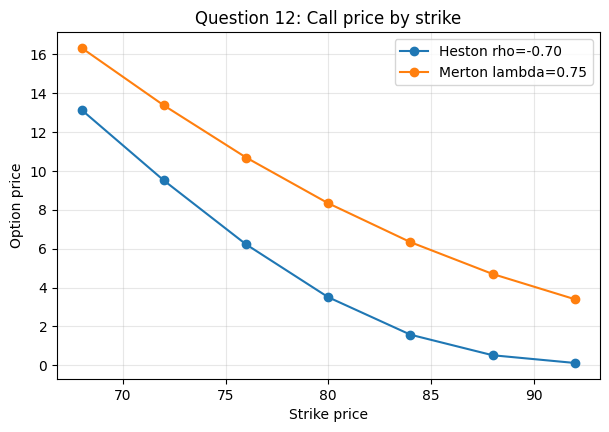

In [63]:
strike_values = np.array([68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0])
strike_rows = []
for strike in strike_values:
    heston_price, _ = discounted_option_price_from_ratios(S0, strike, "call", heston_ratios[-0.70])
    merton_price, _ = discounted_option_price_from_ratios(S0, strike, "call", merton_ratios[0.75])
    moneyness = S0 / strike
    if np.isclose(strike, S0):
        category = "ATM call"
    elif strike > S0:
        category = "OTM call"
    else:
        category = "ITM call"
    strike_rows.append(
        {
            "Question": 12,
            "Strike": strike,
            "Moneyness S/K": moneyness,
            "Category": category,
            "Heston call price (rho=-0.70)": heston_price,
            "Merton call price (lambda=0.75)": merton_price,
        }
    )

strike_sweep = pd.DataFrame(strike_rows)
strike_sweep_display = strike_sweep.copy()
strike_sweep_display["Moneyness S/K"] = strike_sweep_display["Moneyness S/K"].round(3)
strike_sweep_display["Heston call price (rho=-0.70)"] = strike_sweep_display[
    "Heston call price (rho=-0.70)"
].round(2)
strike_sweep_display["Merton call price (lambda=0.75)"] = strike_sweep_display[
    "Merton call price (lambda=0.75)"
].round(2)
display(strike_sweep_display)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(strike_sweep["Strike"], strike_sweep["Heston call price (rho=-0.70)"], marker="o", label="Heston rho=-0.70")
ax.plot(strike_sweep["Strike"], strike_sweep["Merton call price (lambda=0.75)"], marker="o", label="Merton lambda=0.75")
ax.set_title("Question 12: Call price by strike")
ax.set_xlabel("Strike price")
ax.set_ylabel("Option price")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## Question 13 - American call under Heston

With no dividends, early exercise of a call option is not optimal. Therefore the American call has the same value as the corresponding European call under the Heston setting from Question 5. The Delta and Gamma are the Question 7 call Greeks for `rho = -0.30`.


In [64]:
q13_call = heston_greeks.query("Correlation == -0.30 and Option == 'Call'").iloc[0]
american_call = pd.DataFrame(
    [
        {
            "Question": 13,
            "Option": "American call",
            "Correlation": -0.30,
            "Strike": K_ATM,
            "Price": q13_call["Price"],
            "Delta": q13_call["Delta"],
            "Gamma": q13_call["Gamma"],
            "Comment": "Equal to European call because there are no dividends",
        }
    ]
)
american_call_display = american_call.copy()
american_call_display["Price"] = american_call_display["Price"].round(2)
american_call_display["Delta"] = american_call_display["Delta"].round(4)
american_call_display["Gamma"] = american_call_display["Gamma"].round(4)
display(american_call_display)


,Question,Option,Correlation,Strike,Price,Delta,Gamma,Comment
0,13,American call,-0.3,80.0,3.47,0.6037,0.0545,Equal to European call because there are no di...


## Questions 14 and 15 - Barrier options

Question 14 prices a Heston up-and-in call with strike 95 and barrier 95 using the Question 6 setting. Question 15 prices a Merton down-and-in put with strike 65 and barrier 65 using the Question 8 setting.


In [65]:
q14 = heston_up_and_in_call()
q15 = merton_down_and_in_put()
barrier_results = pd.DataFrame(
    [
        {
            "Question": 14,
            "Model": "Heston",
            "Option": "Up-and-in call",
            "Parameter": "rho=-0.70",
            "Strike": 95.0,
            "Barrier": 95.0,
            "Barrier option price": q14["barrier_price"],
            "Comparable vanilla price": q14["vanilla_price"],
            "Barrier hit rate": q14["barrier_hit_rate"],
            "Comment": "Same as vanilla because barrier equals strike and final monitoring is included",
        },
        {
            "Question": 15,
            "Model": "Merton",
            "Option": "Down-and-in put",
            "Parameter": "lambda=0.75",
            "Strike": 65.0,
            "Barrier": 65.0,
            "Barrier option price": q15["barrier_price"],
            "Comparable vanilla price": q15["vanilla_price"],
            "Barrier hit rate": q15["barrier_hit_rate"],
            "Comment": "Same as vanilla because barrier equals strike and final monitoring is included",
        },
    ]
)
barrier_display = barrier_results.copy()
barrier_display["Barrier option price"] = barrier_display["Barrier option price"].round(2)
barrier_display["Comparable vanilla price"] = barrier_display["Comparable vanilla price"].round(2)
barrier_display["Barrier hit rate"] = barrier_display["Barrier hit rate"].round(4)
display(barrier_display)


,Question,Model,Option,Parameter,Strike,Barrier,Barrier option price,Comparable vanilla price,Barrier hit rate,Comment
0,14,Heston,Up-and-in call,rho=-0.70,95.0,95.0,0.03,0.03,0.0224,Same as vanilla because barrier equals strike ...
1,15,Merton,Down-and-in put,lambda=0.75,65.0,65.0,2.78,2.78,0.2579,Same as vanilla because barrier equals strike ...
